# Instructions

- This homework assignment is worth **40** points. 
- Please strive for clarity and organization.
- **AI Usage**:
   - AI use is strictly **prohibited** for conceptual exercises.
   - For applied (Python) exercises, you may only use AI for **debugging**. Do not use AI to generate answers.
- **Due Date: September 18, 2026, by 11:59 PM.**

# Exercise 1 (3 points)

Which method involves rules derived from data patterns, often used in market basket analysis?

- (a) Regression modeling
- (b) Association rules
- (c) Integer programming
- (d) Bayesian networks
- (e) None of the above

a

# Exercise 2 (4 points)

What is one major drawback of using machine learning methods for prescriptive analytics?

ML Models are hart to interpret and blackl boxes. their reccomended actions come with no gaurantee of being optimal or feasible. 

# Exercise 3 (3 points)

Which of the following methods uses probability distributions and pseudo-random numbers to model uncertainty?

- (a) Linear programming
- (b) Data mining
- (c) Monte Carlo simulation
- (d) Decision tree
- (e) None of the above

c

# Exercise 4 (4 points)

Explain why decision trees are considered part of logic-based models in prescriptive analytics.

it's a set of if-then rules mapping conditions to actions. the decision logic is easy to explain and transparent.

# Exercise 5 (3 points)

Which of the following pairs of methods belongs to the **non-stochastic** umbrella of prescriptive analytics?

- (a) Markov decision processes and Monte Carlo simulation
- (b) Mathematical programming and decision trees
- (c) Association rules and clustering
- (d) Queueing theory and genetic algorithms
- (e) None of the above

c

# Exercise 6 (4 points)

The standard error of a Monte Carlo estimator decays at a rate of $\mathcal{O}(1/\sqrt{N})$, where $N$ is the number of simulated samples. Explain what this implies about the computational cost of improving accuracy, and why this rate still makes Monte Carlo attractive for high-dimensional problems.

Having the error requires 4x as many samples. This is expensive. but the rate is independent of dimension, so MC beats grid based methods whose cost grows exponentially w/dimension.

# Exercise 7 (4 points)

Chapter 2 classifies enterprise decision problems by scale-view: operational, tactical, and strategic. Explain why operational problems are typically addressed with non-stochastic methods while tactical and strategic problems call for stochastic (or blended) methods.

operational problemsn are short-horizon and repetetive w/well known inputs, so deterministic methods work, while tactical and strategic horizons involve enough uncertainty that it must be modeled stochastically. 

# Exercise 8 (15 points)

Consider the `ai_dev_productivity.csv` data file. This dataset simulates the productivity of AI developers over 500 days, capturing the subtle interaction between deep work, distractions, caffeine intake, and code quality. Designed to push the limits of machine learning, this data blends behavioral, physiological, and productivity indicators to allow for advanced predictive modeling. This is brief description of each of the columns in the data:

- `hours_coding`: Total focused hours spent on software development work (0–12 hours).
- `coffee_intake_mg`: Daily caffeine intake in milligrams (0–600 mg).
- `distractions`: Number of distractions (e.g., meetings, Slack notifications) (0–10).
- `sleep_hours`: Number of hours of sleep the previous night (3–10 hours).
- `commits`: Number of code commits pushed during the day (0–20).
- `bugs_reported`: Number of bugs reported in code written that day (0–10).
- `ai_usage_hours`: Number of hours spent using AI tools (e.g., ChatGPT, Copilot) (0–12).
- `cognitive_load`: Self-reported mental strain on a scale of 1 to 10. 
- `task_success`: Target column — whether the daily productivity goal was achieved (0/1).

Explore the data and report the insights obtained from the analysis. Create various summary tables and charts. Be sure to explain the insights derived from these tables and charts.

(500, 9)
       hours_coding  coffee_intake_mg  distractions  sleep_hours  commits  \
count        500.00            500.00        500.00       500.00   500.00   
mean           5.02            463.19          2.98         6.98     4.61   
std            1.95            142.33          1.68         1.46     2.70   
min            0.00              6.00          0.00         3.00     0.00   
25%            3.60            369.50          2.00         6.10     3.00   
50%            5.03            500.50          3.00         6.95     5.00   
75%            6.28            600.00          4.00         7.90     6.00   
max           12.00            600.00          8.00        10.00    13.00   

       bugs_reported  ai_usage_hours  cognitive_load  task_success  
count         500.00          500.00          500.00        500.00  
mean            0.86            1.51            4.50          0.61  
std             1.10            1.09            1.87          0.49  
min             0.00 

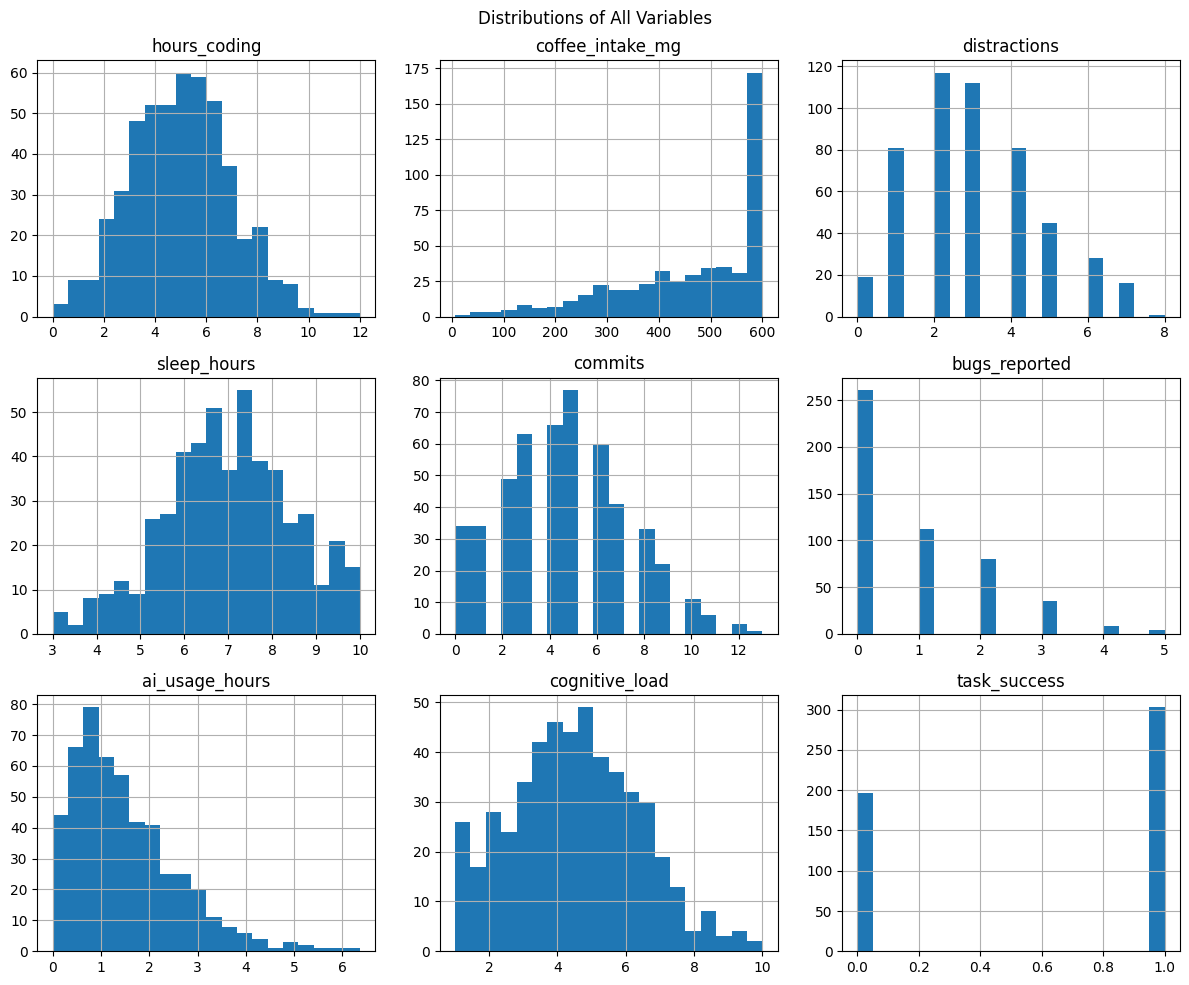

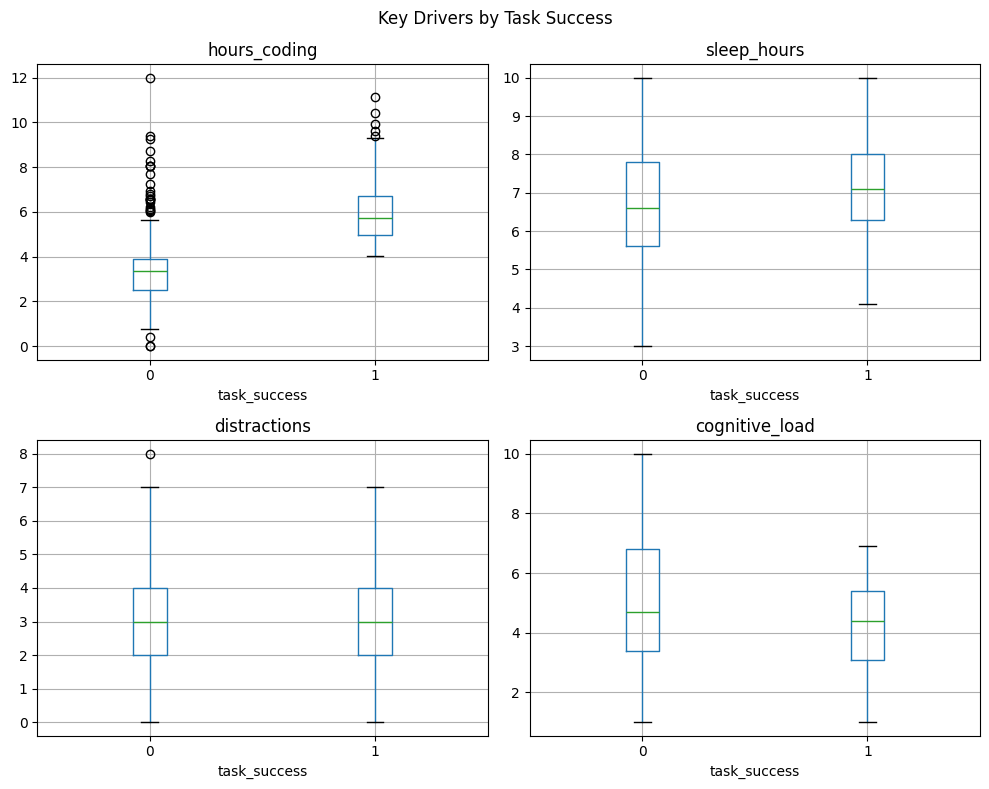

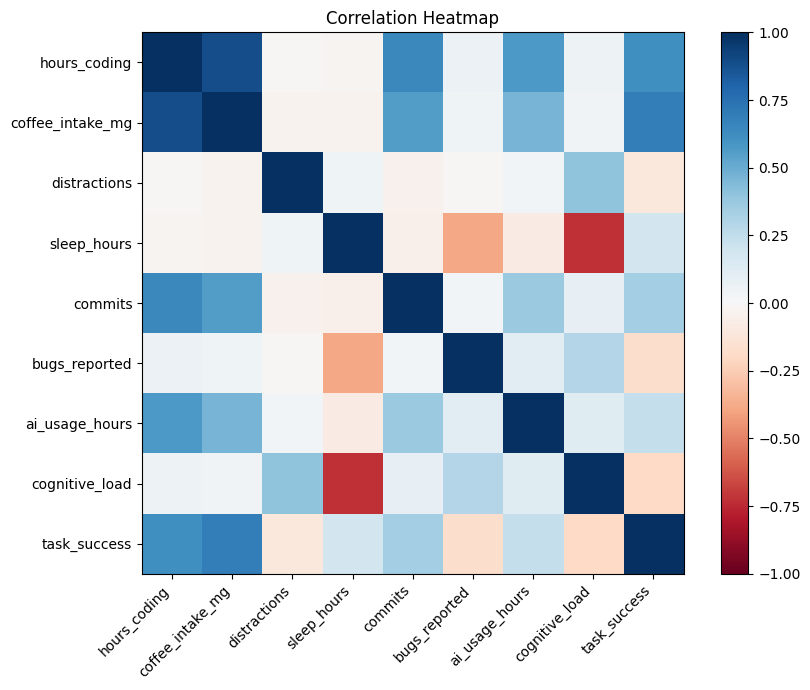

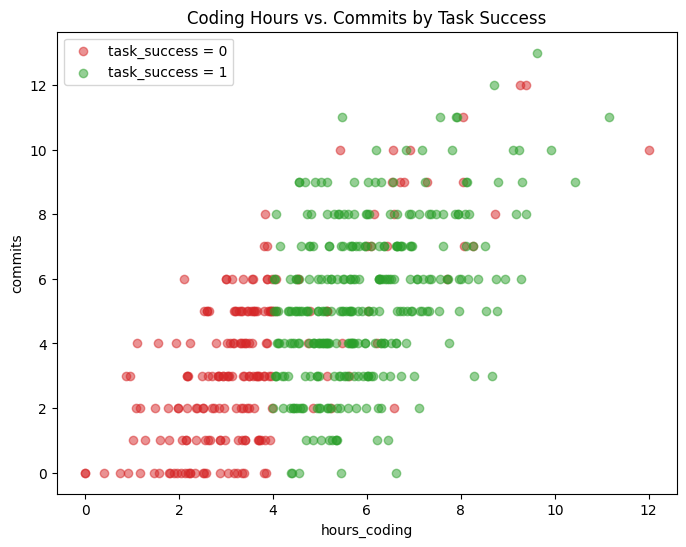

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dev_df = pd.read_csv("DATA/ai_dev_productivity.csv")

print(dev_df.shape)
print(dev_df.describe().round(2))

success_means = dev_df.groupby("task_success").mean().round(2)
print(success_means)

corr = dev_df.corr(numeric_only=True)
print(corr["task_success"].sort_values(ascending=False).round(2))

dev_df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Distributions of All Variables")
plt.tight_layout()
plt.show()

key_vars = ["hours_coding", "sleep_hours", "distractions", "cognitive_load"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, var in zip(axes.ravel(), key_vars):
    dev_df.boxplot(column=var, by="task_success", ax=ax)
    ax.set_xlabel("task_success")
fig.suptitle("Key Drivers by Task Success")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for flag, color in [(0, "tab:red"), (1, "tab:green")]:
    sub = dev_df[dev_df["task_success"] == flag]
    ax.scatter(sub["hours_coding"], sub["commits"], alpha=0.5,
               color=color, label=f"task_success = {flag}")
ax.set_xlabel("hours_coding")
ax.set_ylabel("commits")
ax.legend()
ax.set_title("Coding Hours vs. Commits by Task Success")
plt.show()

# Successful days average 6.0 coding hours vs 3.5, the clearest separation in the data. 
# Coffee intake has the strongest correlation with success (0.70), but it rises with 
# coding hours too, so it appears to mark long days rather than cause success. 
# Successful days also show more sleep (7.2 vs 6.6) and lower cognitive load
# (4.2 vs 5.0). Distractions barely differ between groups (r = -0.10).
# Overall, 61% of days hit the goal.
